# Modelagem e Avaliação

- Este notebook utiliza a base limpa gerado na primeira etapa. Essa base contém apenas tratamentos estruturais, como padronização de nomes de colunas, ajuste de tipos e padronização de categorias.

- Transformações específicas de modelagem, como imputação, encoding, normalização, balanceamento de classes e seleção de features, serão aplicadas somente após a separação entre treino e teste, preferencialmente dentro de Pipeline, para evitar data leakage.

## 1. Imports Iniciais

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib
import json

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

## 2. Carregando a Base

In [2]:
df = pd.read_csv("../data/processed/obesity_clean_eda.csv")

print(df.shape)
df.head()

(2084, 17)


,genero,idade,altura,peso,historico_familia_sobrepeso,freq_alimentos_caloricos,freq_consumo_vegetais,num_refeicoes_diarias,consumo_lanches_entre_refeicoes,fumante,consumo_diario_agua,monitora_calorias_dia,freq_exercicios,tempo_dispositivos_eletronicos,consumo_alcool,meio_transporte,nivel_obesidade
0,Female,21,1.6200,64.0000,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.5200,56.0000,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.8000,77.0000,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.8000,87.0000,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.7800,89.8000,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Definindo Features e Target

In [3]:
TARGET = "nivel_obesidade"

DROP_FEATURES = ["altura", "peso"]

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features utilizadas:")
print(X.columns.tolist())

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Features utilizadas:
['genero', 'idade', 'altura', 'peso', 'historico_familia_sobrepeso', 'freq_alimentos_caloricos', 'freq_consumo_vegetais', 'num_refeicoes_diarias', 'consumo_lanches_entre_refeicoes', 'fumante', 'consumo_diario_agua', 'monitora_calorias_dia', 'freq_exercicios', 'tempo_dispositivos_eletronicos', 'consumo_alcool', 'meio_transporte']

Features shape: (2084, 16)
Target shape: (2084,)


- As variáveis `Altura`, `Peso` e `IMC` foram excluídas da modelagem por estarem diretamente relacionadas à definição dos níveis de obesidade.

- Essa decisão busca evitar que o modelo apenas reproduza uma regra baseada em medidas corporais, em vez de aprender padrões demográficos, comportamentais e de estilo de vida.

- Com isso, a modelagem prioriza variáveis como histórico familiar, hábitos alimentares, atividade física, consumo de água, uso de tecnologia e meio de transporte.

## 4. Ordem dos Níveis de Obesidade

- Definindo uma ordem fixa para facilitar relatórios, gráficos e dashboard.

In [4]:
ordem_niveis = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

## 5. Separar Treino e Teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribuição do target em treino:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribuição do target em teste:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (1667, 16)
X_test: (417, 16)

Distribuição do target em treino:
nivel_obesidade
Obesity_Type_I        0.1690
Obesity_Type_III      0.1550
Obesity_Type_II       0.1420
Overweight_Level_II   0.1380
Normal_Weight         0.1360
Overweight_Level_I    0.1330
Insufficient_Weight   0.1280
Name: proportion, dtype: float64

Distribuição do target em teste:
nivel_obesidade
Obesity_Type_I        0.1680
Obesity_Type_III      0.1560
Obesity_Type_II       0.1440
Overweight_Level_II   0.1390
Normal_Weight         0.1340
Overweight_Level_I    0.1320
Insufficient_Weight   0.1270
Name: proportion, dtype: float64


- Foi utilizada uma divisão estratificada entre conjuntos de treino e teste para preservar a distribuição das classes em ambos os conjuntos. 

## 6. Feature Engineering

Features a serem criadas:

1. `faixa_etaria`

Agrupa a idade em faixas etárias:

- `Abaixo 18`
- `18-30`
- `31-45`
- `46-60`
- `60+`

Com ela nós buscamos capturar possíveis padrões não lineares entre idade e obesidade, já que diferentes faixas etárias podem apresentar hábitos, rotinas e riscos distintos.

2. `transporte_ativo`

Indica se o principal meio de transporte envolve deslocamento ativo, como caminhada ou bicicleta.

Essa feature transforma a variável original de transporte em um indicador comportamental mais direto, relacionado ao nível de atividade física incorporado à rotina.

3. `score_lifestyle`

A variável `score_lifestyle` foi criada como uma pontuação simples para resumir fatores comportamentais associados ao risco de obesidade.

Ela combina os seguintes componentes:

- `historico_familia_sobrepeso`: adiciona risco quando há histórico familiar de sobrepeso;
- `freq_alimentos_caloricos`: adiciona risco quando há consumo frequente de alimentos calóricos;
- `consumo_lanches_entre_refeicoes`: adiciona risco conforme aumenta a frequência de consumo entre refeições;
- `freq_exercicios`: é invertida, pois menor atividade física representa maior risco;
- `tempo_dispositivos_eletronicos`: adiciona risco conforme aumenta o tempo de uso de tecnologia;
- `monitora_calorias_dia`: reduz o score quando há monitoramento do consumo calórico, tratado como possível fator de proteção.

A lógica é: quanto maior o `score_lifestyle`, maior a concentração de fatores comportamentais considerados desfavoráveis. No entanto, essa variável não é uma escala clínica validada. Ela é uma característica exploratória criada com base nas hipóteses da EDA para ajudar o modelo a capturar combinações de hábitos em uma única feature.

In [6]:
def add_features(data):
    
    df_feature = data.copy()

    # Faixa etária
    df_feature["faixa_etaria"] = pd.cut(
        df_feature["idade"],
        bins=[0, 18, 30, 45, 60, 120],
        labels=["Abaixo 18", "18-30", "31-45", "46-60", "60+"],
        include_lowest=True
    )

    # Transporte ativo
    df_feature["transporte_ativo"] = df_feature["meio_transporte"].isin(["Walking", "Bike"]).astype(int)

    # Indicadores binários de estilo de vida
    risco_alimento_cal = df_feature["freq_alimentos_caloricos"].map({"no": 0, "yes": 1}).fillna(0)
    risco_familia = df_feature["historico_familia_sobrepeso"].map({"no": 0, "yes": 1}).fillna(0)
    monitora_caloria = df_feature["monitora_calorias_dia"].map({"no": 0, "yes": 1}).fillna(0)

    # NVariáveis comportamentais numéricas
    freq_exercicio = 3 - df_feature["freq_exercicios"]
    uso_tecnologia = df_feature["tempo_dispositivos_eletronicos"]
    
    # Mapeamento ordinal 
    consumo_map = {
        "no": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }
    risco_consumo = df_feature["consumo_lanches_entre_refeicoes"].map(consumo_map).fillna(0)

    # Lifestyle score
    df_feature["score_lifestyle"] = (
        risco_familia
        + risco_alimento_cal
        + risco_consumo
        + freq_exercicio
        + uso_tecnologia
        - monitora_caloria
    )

    return df_feature

## 7. Definindo Tipos de Features após Feature Engineering

In [7]:
numeric_features = [
    "idade",
    "freq_consumo_vegetais",
    "num_refeicoes_diarias",
    "consumo_diario_agua",
    "freq_exercicios",
    "tempo_dispositivos_eletronicos",
    "score_lifestyle"
]

categorical_features = [
    "genero",
    "historico_familia_sobrepeso",
    "freq_alimentos_caloricos",
    "consumo_lanches_entre_refeicoes",
    "fumante",
    "monitora_calorias_dia",
    "consumo_alcool",
    "meio_transporte",
    "faixa_etaria",
    "transporte_ativo"
]

## 8. Criando um Transformador de Features

A função `add_features` foi encapsulada com `FunctionTransformer` para torná-la compatível com o fluxo de modelagem do scikit-learn.

Essa etapa permite que a criação das features derivadas seja incluída diretamente no `Pipeline`, garantindo que as mesmas transformações sejam aplicadas de forma consistente durante o treinamento, avaliação e futura utilização do modelo.

In [8]:
feature_engineering = FunctionTransformer(
    add_features,
    validate=False
)

## 9. Pré-processamento

### 9.1. Pipeline Numérica

Foi criado um pipeline específico para o pré-processamento das variáveis numéricas.

Esse pipeline possui duas etapas:

1. `SimpleImputer(strategy="median")`: preenche valores ausentes com a mediana da respectiva variável numérica. A mediana foi escolhida por ser mais robusta a outliers do que a média.
2. `StandardScaler()`: padroniza as variáveis numéricas, aplicando a transformação de z-score. Essa transformação remove a média e divide pelo desvio padrão, colocando as variáveis em uma escala comum.

Essa padronização é importante para modelos sensíveis à escala dos dados, como Regressão Logística, KNN e SVM.

Como essas transformações serão usadas dentro de um `Pipeline`, os parâmetros de imputação e escala serão aprendidos apenas com os dados de treino, reduzindo o risco de vazamento de dados.

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

### 9.2 Pipeline Categórica

Da mesma forma, foi criado um pipeline específico para o pré-processamento das variáveis categóricas.

Esse pipeline possui duas etapas:

1. `SimpleImputer(strategy="most_frequent")`: preenche valores ausentes com a categoria mais frequente de cada variável categórica.
2. `OneHotEncoder(handle_unknown="ignore")`: transforma categorias em variáveis binárias, permitindo que modelos de machine learning utilizem informações categóricas.

O parâmetro `handle_unknown="ignore"` foi utilizado para evitar erros caso apareçam categorias novas no conjunto de teste ou em dados futuros.

In [10]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

### 9.3 Pré-processador Geral Utilizando o `ColumnTransformer`

O `ColumnTransformer` aplica diferentes estratégias de pré-processamento as variáveis numéricas e categóricas.

Essa estrutura permite centralizar o pré-processamento em uma única etapa, garantindo maior organização, reprodutibilidade e compatibilidade com o `Pipeline` de modelagem.

Quando utilizado dentro do pipeline completo, o `ColumnTransformer` é ajustado apenas com os dados de treino, reduzindo o risco de vazamento de dados.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 10. Função para Construir Pipelines dos Modelos

A função `build_pipeline()` serve para montar o fluxo completo de modelagem de forma reutilizável.

O pipeline é composto por três etapas:

1. `feature_engineering`: cria features.
2. `preprocessor`: aplica o pré-processamento das variáveis numéricas e categóricas.
3. `model`: recebe o algoritmo de machine learning que será treinado.

Essa estrutura permite testar diferentes modelos mantendo o mesmo processo de preparação dos dados, garantindo maior consistência na comparação dos resultados.

In [12]:
def build_pipeline(model):
    pipeline = Pipeline(
        steps=[
            ("feature_engineering", feature_engineering),
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    return pipeline

## 11. Baseline e Modelos Candidatos

Aqui foram definidos os modelos candidatos que serão avaliados no projeto.

O objetivo é comparar algoritmos com diferentes níveis de complexidade, desde um baseline simples até modelos não lineares mais robustos.

Foram incluídos:
1. `DummyClassifier`: baseline ingênuo que sempre prevê a classe mais frequente.
2. `LogisticRegression`: modelo linear e interpretável.
3. `KNeighborsClassifier`: modelo baseado em proximidade entre observações.
4. `SVC`: modelo de margem com kernel não linear.
5. `RandomForestClassifier`: ensemble de árvores de decisão.
6. `ExtraTreesClassifier`: ensemble de árvores com maior aleatoriedade.
7. `HistGradientBoostingClassifier`: modelo de boosting baseado em árvores.

Alguns modelos utilizam `class_weight="balanced"` para reduzir o impacto de possíveis diferenças na distribuição das classes.

A definição dos modelos em um dicionário permite iterar automaticamente sobre eles, construir pipelines de forma padronizada e comparar seus resultados usando as mesmas métricas e a mesma estratégia de validação cruzada.

In [13]:
models = {
    "DummyClassifier": DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),

    "KNeighborsClassifier": KNeighborsClassifier(
        n_neighbors=7
    ),

    "SVC": SVC(
        kernel="rbf",
        C=5,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTreesClassifier": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=31,
        random_state=42
    )
}

## 12. Validação Cruzada

A validação cruzada foi configurada com `StratifiedKFold`, utilizando 5 divisões.

A opção por validação estratificada foi feita porque o problema envolve classificação multiclasse. Essa estratégia preserva aproximadamente a proporção das classes em cada fold, tornando a avaliação mais estável e reduzindo o risco de folds com distribuição de classes distorcida.

O parâmetro `shuffle=True` embaralha os dados antes da criação dos folds, enquanto `random_state=42` garante reprodutibilidade dos resultados.

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro"
}

## 13. Comparar Modelos

In [15]:
def plot_model_dashboard (
    estimator,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Model",
    cv=5,
    scoring="f1_macro",
    save_path=None
):
    
    # Clona o estimador para evitar alteração do original
    model = clone(estimator)
    model.fit(X_train, y_train)

    # Predições
    y_pred = model.predict(X_test)

    # Classes
    class_names = np.unique(y_train)

    # Métricas gerais
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    precision_macro = precision_score(y_test, y_pred, average="macro")
    recall_macro = recall_score(y_test, y_pred, average="macro")

    # Figura
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f"Relatório de Qualidade: {model_name}", fontsize=18, fontweight="bold")


    # Matriz de Confusão

    ax_cm = axes[0, 0]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=class_names,
        cmap="YlGnBu",
        xticks_rotation=45,
        ax=ax_cm,
        colorbar=False
    )
    ax_cm.set_title("Matriz de Confusão")
    ax_cm.grid(False)


    # Classification Report

    ax_cr = axes[0, 1]
    ax_cr.axis("off")

    report_dict = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).T.round(3)

    rows_to_show = list(class_names) + ["accuracy", "macro avg", "weighted avg"]
    rows_to_show = [row for row in rows_to_show if row in report_df.index]
    report_df = report_df.loc[rows_to_show]

    table = ax_cr.table(
        cellText=report_df.values,
        rowLabels=report_df.index,
        colLabels=report_df.columns,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.15, 1.6)

    ax_cr.set_title("Classification Report", pad=20)

    resumo = (
        f"Accuracy: {acc:.4f}\n"
        f"Macro F1-score: {f1_macro:.4f}\n"
        f"Weighted F1-score: {f1_weighted:.4f}\n"
        f"Macro Precision: {precision_macro:.4f}\n"
        f"Macro Recall: {recall_macro:.4f}"
    )

    ax_cr.text(
        0.02,
        -0.15,
        resumo,
        transform=ax_cr.transAxes,
        fontsize=11,
        va="top"
    )


    # Curva de Aprendizado

    ax_lc = axes[1, 0]

    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=clone(estimator),
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.3, 1.0, 5)
    )

    train_scores_mean = train_scores.mean(axis=1)
    valid_scores_mean = valid_scores.mean(axis=1)

    ax_lc.plot(train_sizes, train_scores_mean, marker="o", label="Treino")
    ax_lc.plot(train_sizes, valid_scores_mean, marker="o", label="Validação")

    ax_lc.set_title(f"Curva de Aprendizado ({scoring})")
    ax_lc.set_xlabel("Amostras de Treino")
    ax_lc.set_ylabel(scoring)
    ax_lc.legend()
    ax_lc.grid(True, alpha=0.3)

    # Curva ROC Multiclasse
   
    ax_roc = axes[1, 1]

    y_test_bin = label_binarize(y_test, classes=class_names)

    y_score = None

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    if y_score is not None:
        for i, class_label in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, lw=2, label=f"{class_label} (AUC = {roc_auc:.2f})")

        ax_roc.plot([0, 1], [0, 1], linestyle="--", color="black")
        ax_roc.set_title("Curva ROC (One-vs-Rest)")
        ax_roc.set_xlabel("False Positive Rate")
        ax_roc.set_ylabel("True Positive Rate")
        ax_roc.legend(loc="lower right", fontsize=9)
        ax_roc.grid(True, alpha=0.3)
    else:
        ax_roc.axis("off")
        ax_roc.text(
            0.5,
            0.5,
            "ROC não disponível\n(modelo sem predict_proba ou decision_function)",
            ha="center",
            va="center",
            fontsize=12
        )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    metrics_dict = {
        "modelo": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro
    }

    return model, metrics_dict

In [16]:
cv_results = []

for model_name, model in models.items():
    print(f"Treinando: {model_name}")

    pipeline = build_pipeline(model)

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    cv_results.append({
        "modelo": model_name,
        "train_accuracy_mean": scores["train_accuracy"].mean(),
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "cv_precision_macro_mean": scores["test_precision_macro"].mean(),
        "cv_recall_macro_mean": scores["test_recall_macro"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="cv_f1_macro_mean",
    ascending=False
)

cv_results_df

Training: DummyClassifier
Training: LogisticRegression
Training: KNeighborsClassifier
Training: SVC
Training: RandomForestClassifier
Training: ExtraTreesClassifier
Training: HistGradientBoostingClassifier


,model,train_accuracy_mean,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_weighted_mean,cv_precision_macro_mean,cv_recall_macro_mean
4,RandomForestClassifier,0.9738,0.7990,0.0204,0.7927,0.7959,0.7944,0.7957
6,HistGradientBoostingClassifier,0.9868,0.7966,0.0140,0.7911,0.7943,0.7923,0.7934
5,ExtraTreesClassifier,0.9832,0.7954,0.0168,0.7905,0.7937,0.7931,0.7918
3,SVC,0.9094,0.7750,0.0292,0.7671,0.7705,0.7669,0.7719
2,KNeighborsClassifier,0.7567,0.6778,0.0220,0.6433,0.6500,0.6643,0.6677
1,LogisticRegression,0.6303,0.6047,0.0142,0.5810,0.5861,0.5865,0.5997
0,DummyClassifier,0.1686,0.1686,0.0011,0.0412,0.0486,0.0241,0.1429


In [17]:
top_models = [
    "RandomForestClassifier",
    "HistGradientBoostingClassifier",
    "ExtraTreesClassifier",
    "SVC"
]


Gerando painel para: RandomForestClassifier


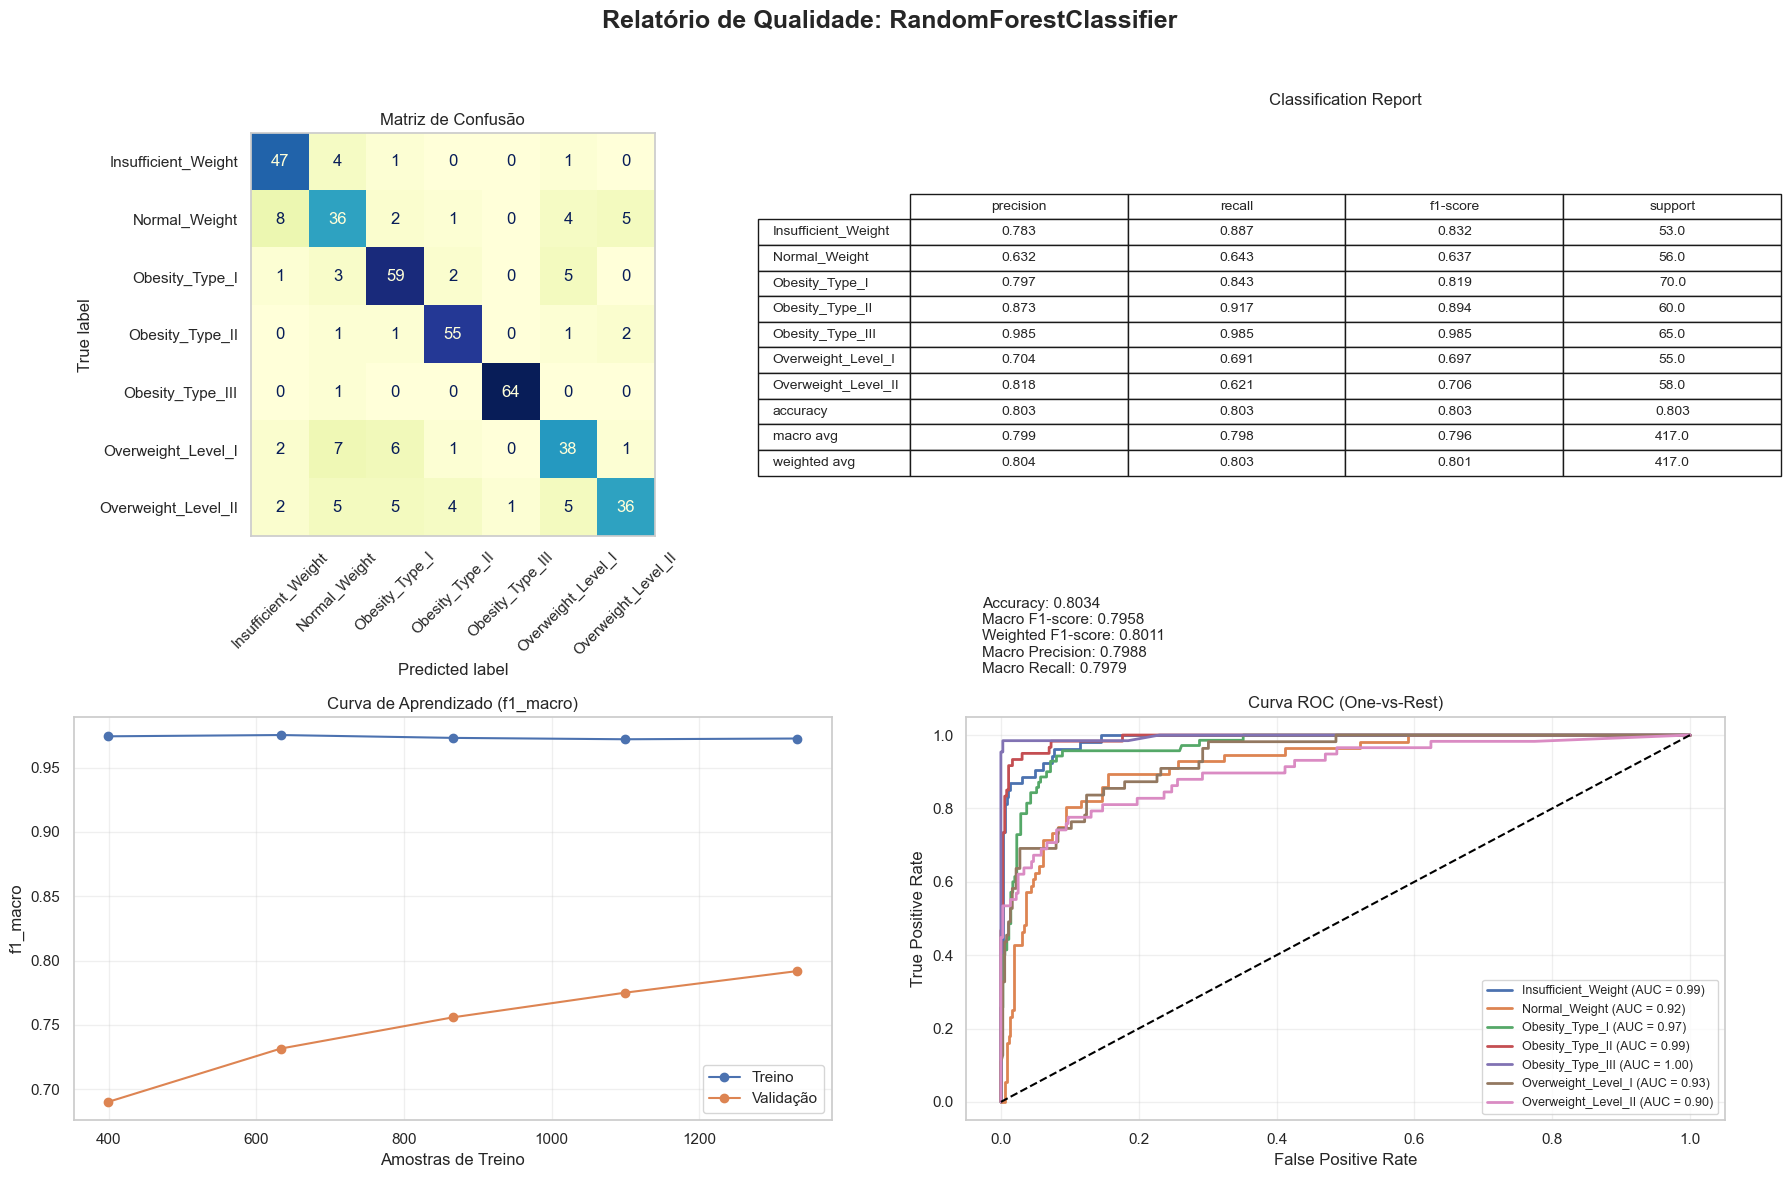


Gerando painel para: HistGradientBoostingClassifier


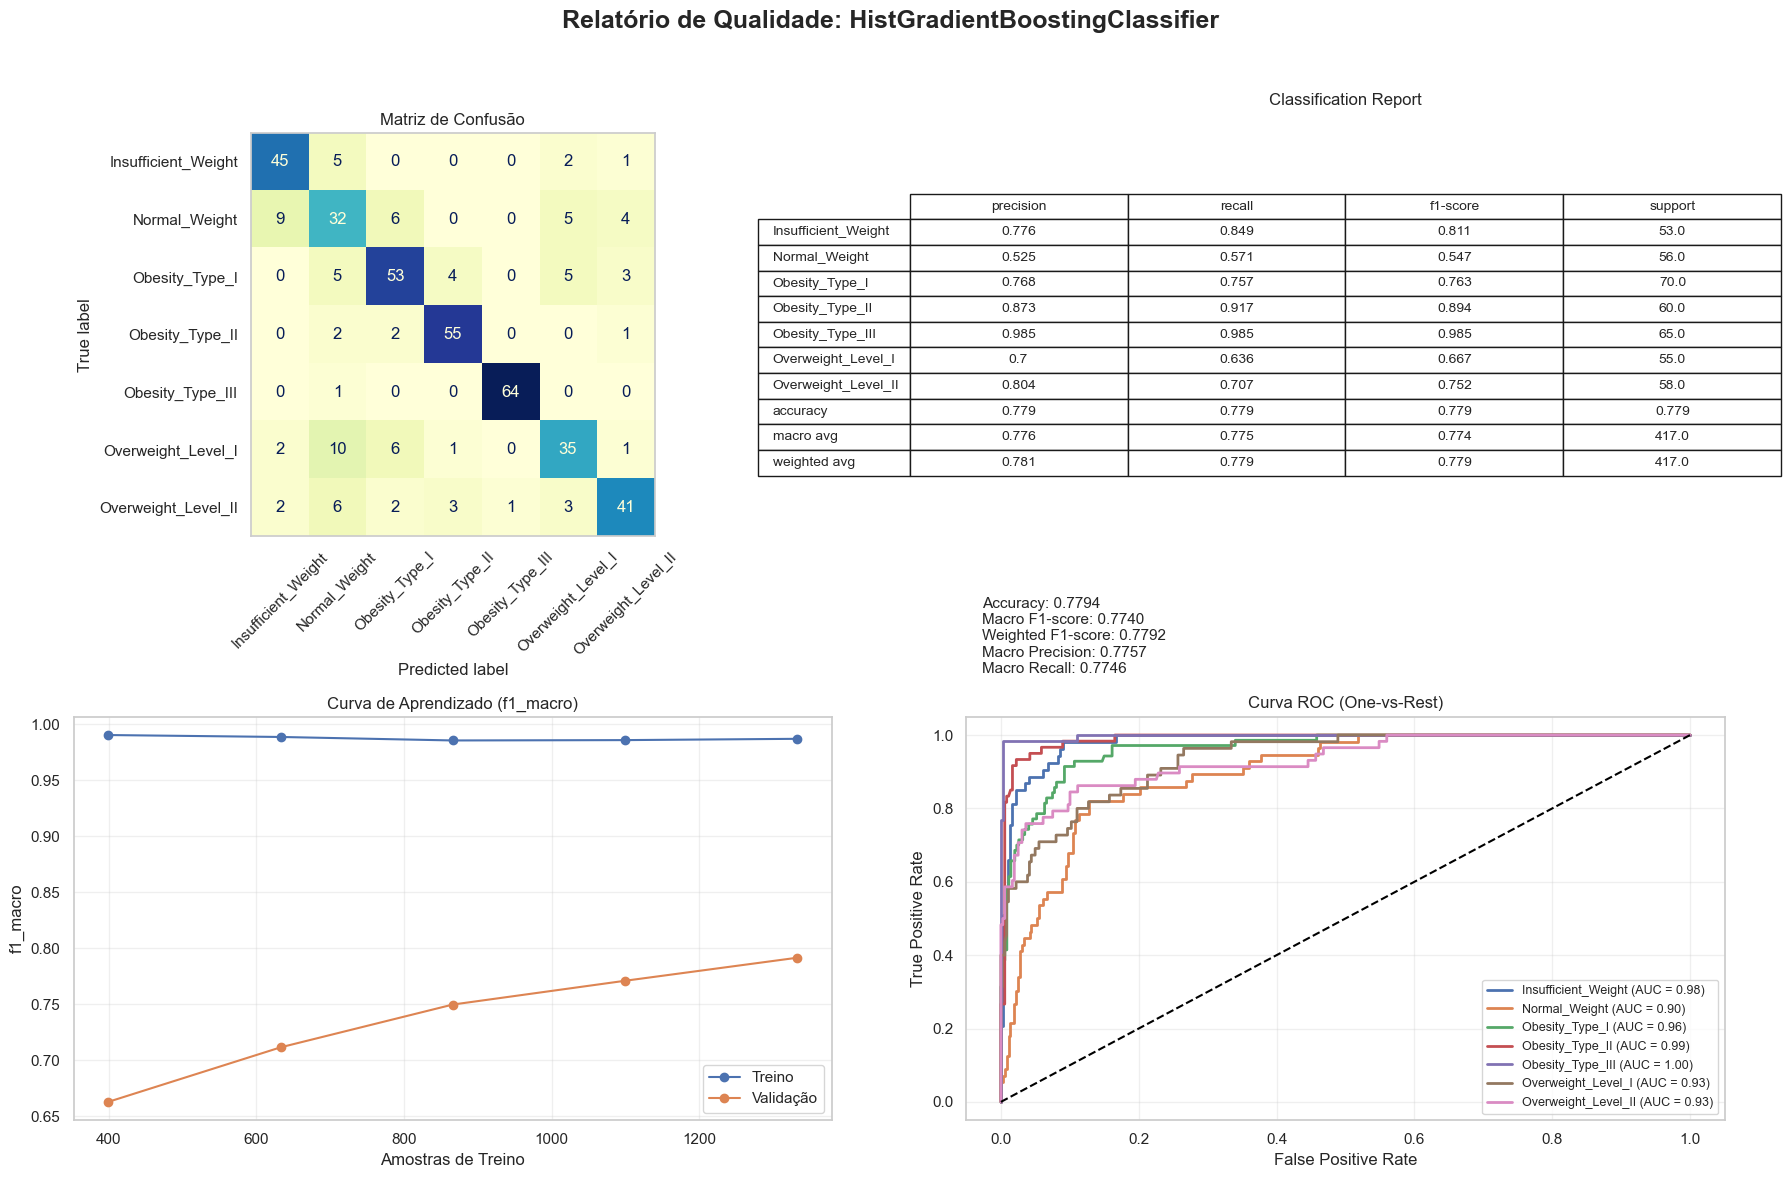


Gerando painel para: ExtraTreesClassifier


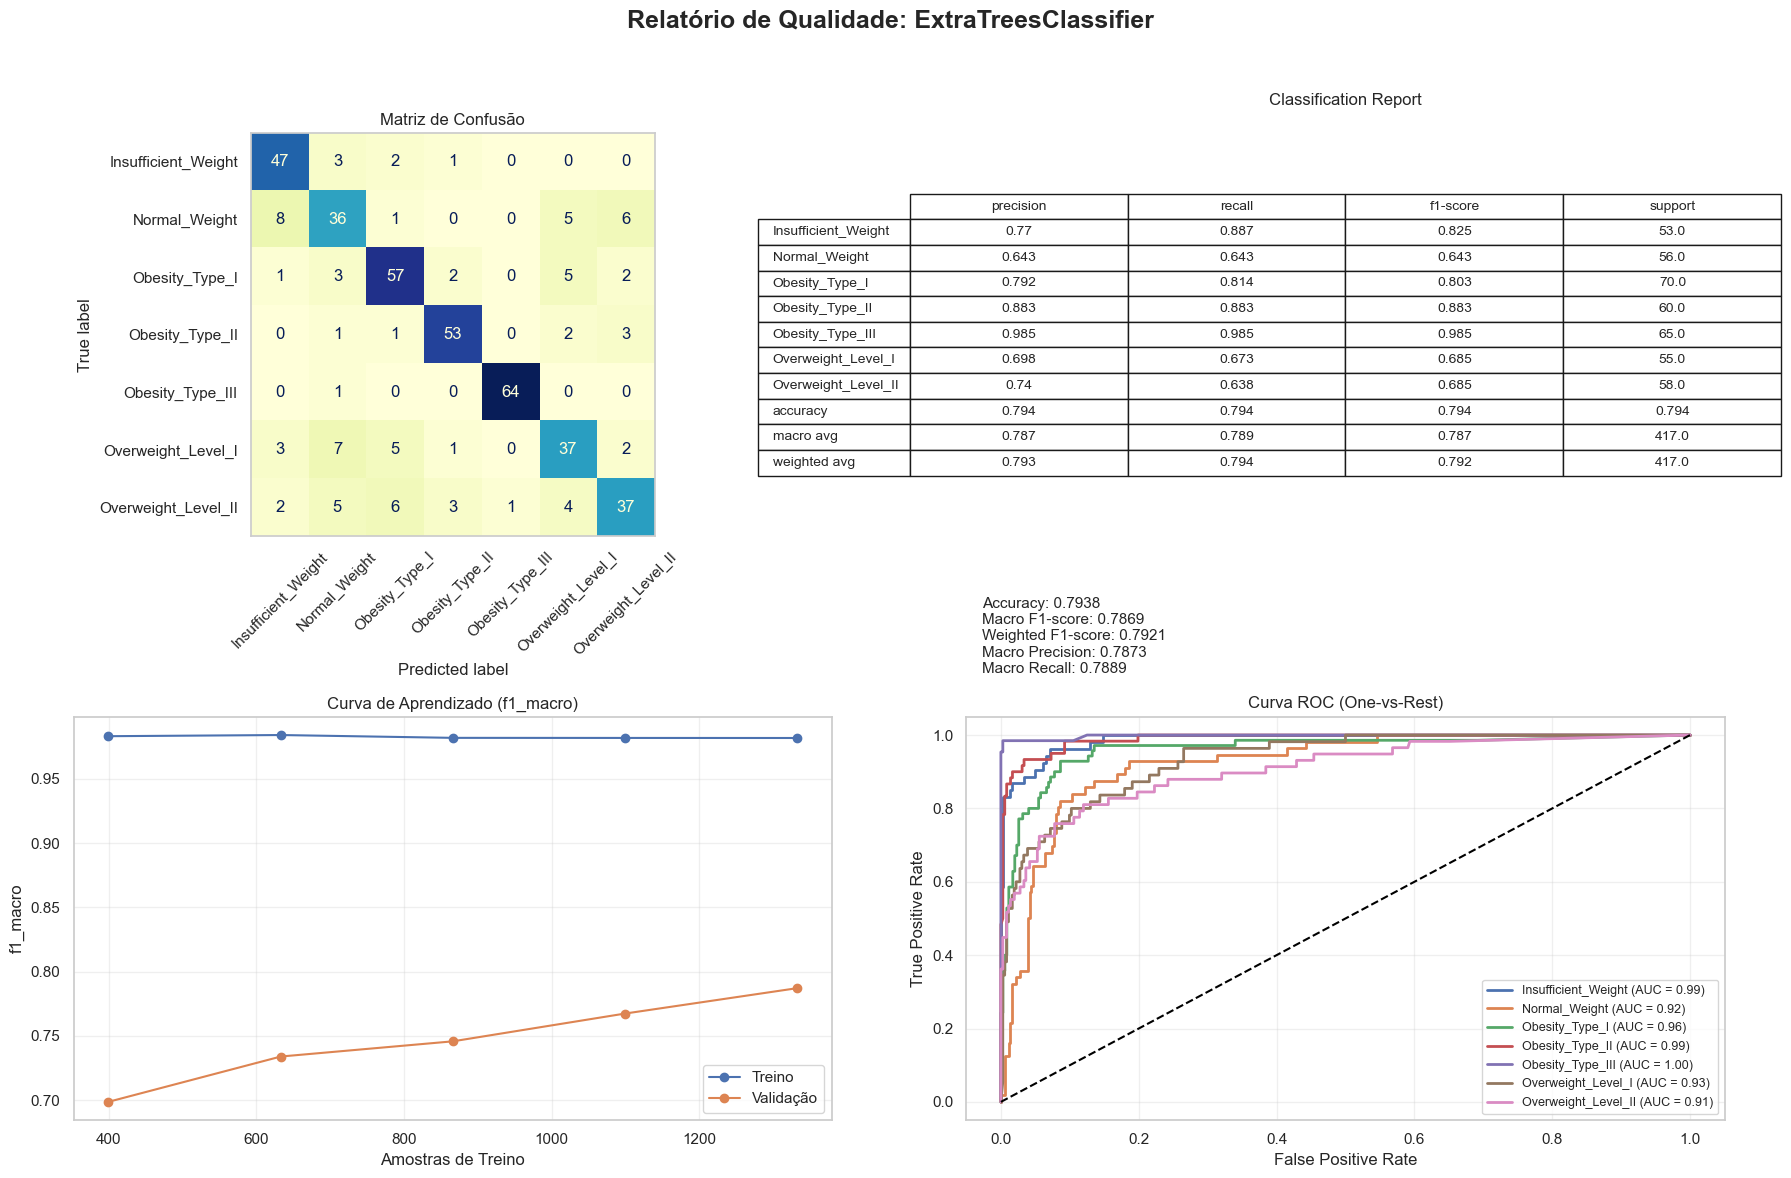


Gerando painel para: SVC


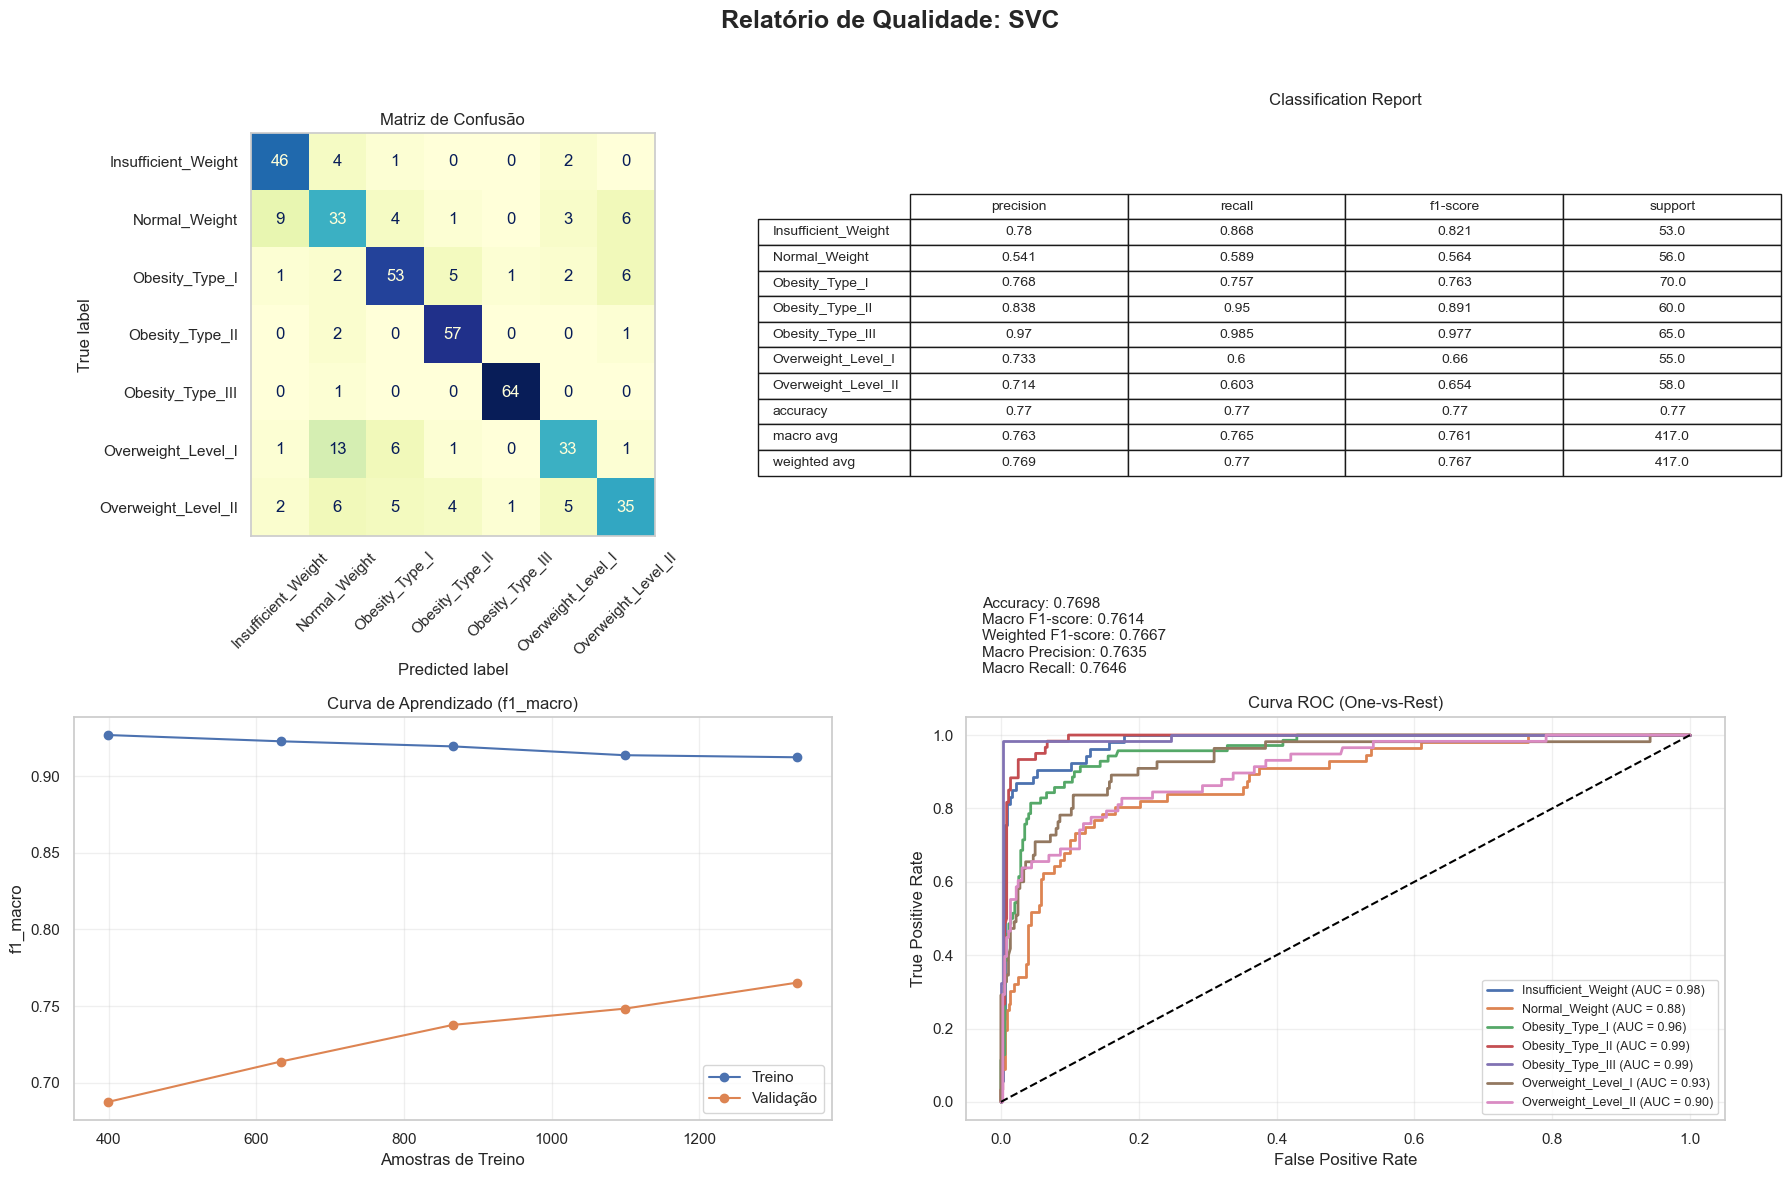

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,RandomForestClassifier,0.8034,0.7958,0.8011,0.7988,0.7979
2,ExtraTreesClassifier,0.7938,0.7869,0.7921,0.7873,0.7889
1,HistGradientBoostingClassifier,0.7794,0.7740,0.7792,0.7757,0.7746
3,SVC,0.7698,0.7614,0.7667,0.7635,0.7646


In [18]:
dashboard_results = []

for model_name in top_models:
    print(f"\nGerando painel para: {model_name}")

    pipeline = build_pipeline(models[model_name])

    fitted_model, metrics = plot_model_dashboard(
        estimator=pipeline,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        model_name=model_name,
        cv=5,
        scoring="f1_macro",
        save_path=f"../reports/figures/{model_name.lower()}_dashboard.png"
    )

    dashboard_results.append(metrics)

dashboard_results_df = pd.DataFrame(dashboard_results).sort_values(
    by="macro_f1", ascending=False
)

dashboard_results_df

A comparação entre os modelos indica que os algoritmos baseados em árvores apresentaram o melhor desempenho geral. Entre eles, o `RandomForestClassifier` obteve o melhor equilíbrio entre as métricas avaliadas, alcançando no conjunto de teste:

- Accuracy: 0.8034
- Macro F1-score: 0.7958
- Weighted F1-score: 0.8011
- Macro Precision: 0.7988
- Macro Recall: 0.7979

O desempenho no conjunto de teste ficou próximo ao observado na validação cruzada, o que indica boa consistência entre as etapas de validação e avaliação final.

O `ExtraTreesClassifier` apresentou desempenho muito próximo ao Random Forest, sendo também um modelo competitivo. O `HistGradientBoostingClassifier` teve bons resultados na validação cruzada, mas apresentou desempenho ligeiramente inferior no conjunto de teste. O `SVC` superou a meta mínima de accuracy, porém ficou abaixo dos principais modelos baseados em árvores. Já `KNeighborsClassifier` e `LogisticRegression` tiveram desempenho inferior e não foram considerados os melhores candidatos para o modelo final.

As matrizes de confusão mostram que os modelos tendem a classificar melhor as categorias mais extremas, como `Insufficient_Weight`, `Obesity_Type_II` e `Obesity_Type_III`. As maiores dificuldades aparecem nas categorias intermediárias, especialmente `Normal_Weight`, `Overweight_Level_I` e `Overweight_Level_II`. Esse comportamento é esperado, pois essas classes representam transições graduais entre estados nutricionais e tendem a compartilhar características comportamentais semelhantes.

As curvas de aprendizado indicam diferença entre o desempenho de treino e validação, sugerindo algum nível de overfitting. No entanto, essa diferença não se refletiu em uma queda relevante no conjunto de teste.

As curvas ROC One-vs-Rest também indicam boa capacidade de separação entre as classes, especialmente nas categorias mais extremas. Ainda assim, para este problema multiclasse, a seleção do modelo final foi baseada principalmente em accuracy, macro F1-score, macro precision, macro recall e análise da matriz de confusão.

Dessa forma, o `RandomForestClassifier` foi selecionado como modelo final por apresentar o melhor desempenho geral, boa consistência entre validação cruzada e teste, e performance adequada mesmo sem o uso de variáveis antropométricas como `altura`, `peso` e `IMC`.

## 14. Analisar Overfitting

In [19]:
cv_results_df["overfit_gap"] = (
    cv_results_df["train_accuracy_mean"] - cv_results_df["cv_accuracy_mean"]
)

cv_results_df.sort_values(by="cv_f1_macro_mean", ascending=False)

,model,train_accuracy_mean,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_weighted_mean,cv_precision_macro_mean,cv_recall_macro_mean,overfit_gap
4,RandomForestClassifier,0.9738,0.7990,0.0204,0.7927,0.7959,0.7944,0.7957,0.1747
6,HistGradientBoostingClassifier,0.9868,0.7966,0.0140,0.7911,0.7943,0.7923,0.7934,0.1902
5,ExtraTreesClassifier,0.9832,0.7954,0.0168,0.7905,0.7937,0.7931,0.7918,0.1878
3,SVC,0.9094,0.7750,0.0292,0.7671,0.7705,0.7669,0.7719,0.1344
2,KNeighborsClassifier,0.7567,0.6778,0.0220,0.6433,0.6500,0.6643,0.6677,0.0789
1,LogisticRegression,0.6303,0.6047,0.0142,0.5810,0.5861,0.5865,0.5997,0.0256
0,DummyClassifier,0.1686,0.1686,0.0011,0.0412,0.0486,0.0241,0.1429,0.0000


Para avaliar possíveis sinais de overfitting, foi criada a variável `overfit_gap`, calculada como a diferença entre a accuracy média no treino e a accuracy média na validação cruzada.

Um valor alto de `overfit_gap` indica que o modelo teve desempenho muito melhor nos dados de treino do que nos dados de validação, o que pode sugerir overfitting. Por outro lado, valores menores indicam maior proximidade entre treino e validação e, portanto, melhor capacidade de generalização.

Os modelos baseados em árvores apresentaram os melhores desempenhos em validação cruzada, mas também os maiores gaps entre treino e validação. 

A análise final de overfitting deve considerar também o desempenho no conjunto de teste. Caso o desempenho em teste permaneça próximo ao desempenho da validação cruzada, o overfitting observado no treino pode ser considerado controlado.

## 15. Escolher Modelos Candidatos

In [20]:
top_n = 3

top_models = (
    cv_results_df
    .sort_values(by="cv_f1_macro_mean", ascending=False)
    .head(top_n)["model"]
    .tolist()
)

top_models

['RandomForestClassifier',
 'HistGradientBoostingClassifier',
 'ExtraTreesClassifier']

## 16. Avaliar no Conjunto de Teste

In [21]:
test_results = []
fitted_models = {}

for model_name in top_models:
    print(f"Treinando e testando: {model_name}")

    pipeline = build_pipeline(models[model_name])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    fitted_models[model_name] = pipeline

    test_results.append({
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "test_precision_macro": precision_score(y_test, y_pred, average="macro"),
        "test_recall_macro": recall_score(y_test, y_pred, average="macro")
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(by="test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

test_results_df

Training and testing: RandomForestClassifier
Training and testing: HistGradientBoostingClassifier
Training and testing: ExtraTreesClassifier


,model,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro
0,RandomForestClassifier,0.8034,0.7958,0.8011,0.7988,0.7979
1,ExtraTreesClassifier,0.7938,0.7869,0.7921,0.7873,0.7889
2,HistGradientBoostingClassifier,0.7794,0.7740,0.7792,0.7757,0.7746


In [22]:
best_model_name = test_results_df.loc[0, "model"]
best_model_name

'RandomForestClassifier'

In [23]:
final_pipeline = fitted_models[best_model_name]
final_pipeline

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_features at 0x000002D3A58A2C00>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['idade',
                                                   'freq_consumo_vegetais',
                                                   'num_refeicoes_diarias',
                                                   'consumo_diario_agua',
                                                   'freq_exercicios...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero',
                                                   'historico_familia_sobrepeso',
                                                   'freq_alimentos_caloricos',
                                                   'consumo_lanches_entre_refeicoes',
                                                   'fumante',
                                                   'monitora_calorias_dia',
                                                   'consumo_alcool',
                                                   'meio_transporte',
                                                   'faixa_etaria',
                                                   'transporte_ativo'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_split=4, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

Após a validação cruzada, os três melhores modelos foram selecionados automaticamente com base no `cv_f1_macro_mean`.

O macro F1-score foi utilizado como critério principal porque o problema envolve classificação multiclasse e essa métrica avalia o desempenho médio entre os níveis de obesidade, sem favorecer apenas os mais frequentes.

Os três modelos selecionados foram então treinados novamente com todo o conjunto de treino e avaliados no conjunto de teste. A seleção final foi feita com base no melhor desempenho no teste, considerando principalmente `test_f1_macro`, além de accuracy, precision macro e recall macro.

Embora os modelos tenham apresentado diferençsa entre seus desempenhos de treino e validação, o resultado no teste não mostrou queda relevante de performance. Portanto, não há evidência de overfitting severo na avaliação final.

Ainda assim, a análise será complementada com classification report e matriz de confusão para verificar o desempenho individual em cada nível de obesidade.

## 17. Relatório de Classificação

In [24]:
y_pred_final = final_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_final))

                     precision    recall  f1-score   support

Insufficient_Weight       0.78      0.89      0.83        53
      Normal_Weight       0.63      0.64      0.64        56
     Obesity_Type_I       0.80      0.84      0.82        70
    Obesity_Type_II       0.87      0.92      0.89        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.70      0.69      0.70        55
Overweight_Level_II       0.82      0.62      0.71        58

           accuracy                           0.80       417
          macro avg       0.80      0.80      0.80       417
       weighted avg       0.80      0.80      0.80       417



## 18. Matriz de Confusão

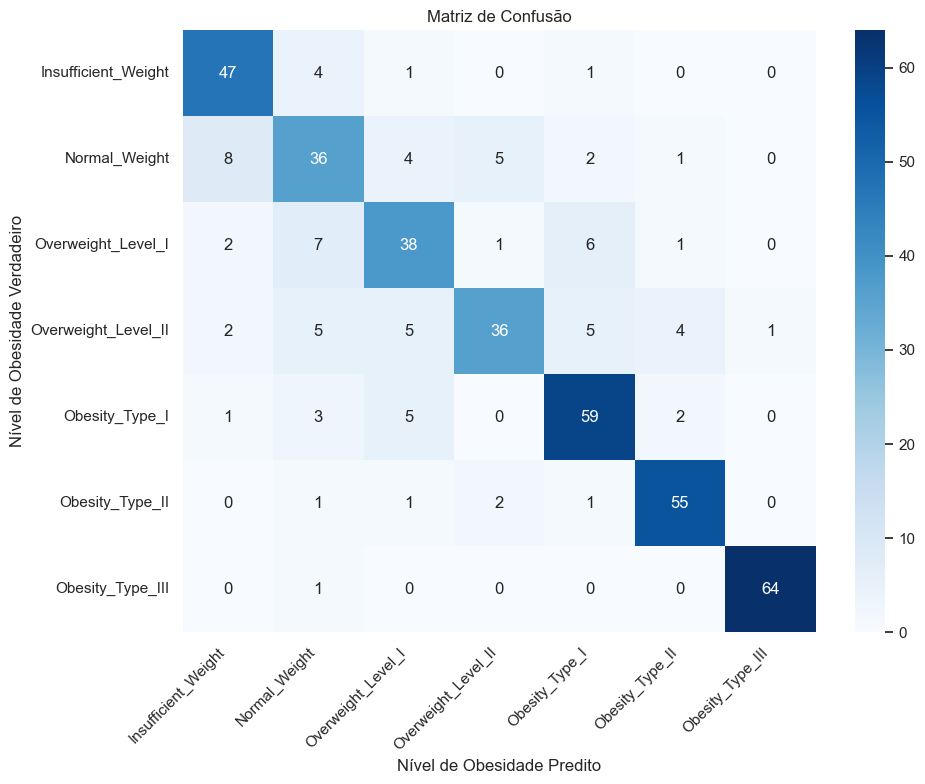

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=ordem_niveis
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ordem_niveis,
    yticklabels=ordem_niveis
)

plt.title("Matriz de Confusão")
plt.xlabel("Nível de Obesidade Predito")
plt.ylabel("Nível de Obesidade Verdadeiro")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Tuning: GridSearch para Random Forest

In [26]:
rf_pipeline = build_pipeline(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
)

param_grid_rf = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 8, 12, 16],
    "model__min_samples_split": [2, 4, 8],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_rf.best_params_)

print("Melhor CV macro F1:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Melhores parâmetros:
{'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 800}
Melhor CV macro F1:
0.7931971942419249


In [29]:
best_rf_pipeline = grid_rf.best_estimator_

y_pred_rf = best_rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=ordem_niveis,
        target_names=ordem_niveis
    )
)

Accuracy: 0.8009592326139089
Macro F1: 0.7938580336832585
                     precision    recall  f1-score   support

Insufficient_Weight       0.78      0.89      0.83        53
      Normal_Weight       0.62      0.64      0.63        56
 Overweight_Level_I       0.70      0.69      0.70        55
Overweight_Level_II       0.86      0.62      0.72        58
     Obesity_Type_I       0.79      0.81      0.80        70
    Obesity_Type_II       0.85      0.93      0.89        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.80       417
          macro avg       0.80      0.80      0.79       417
       weighted avg       0.80      0.80      0.80       417



Após a comparação inicial dos modelos, o `RandomForestClassifier` foi selecionado para uma etapa de ajuste de hiperparâmetros, por ter apresentado o melhor desempenho geral na validação cruzada.

Com o `GridSearchCV` testamos diferentes combinações de parâmetros do Random Forest dentro do pipeline completo de modelagem. A busca considerou variações em número de árvores, profundidade máxima, número mínimo de amostras para divisão de nós, número mínimo de amostras por folha e número de features consideradas em cada divisão.

Como o modelo está inserido em um `Pipeline`, os parâmetros foram definidos com o prefixo `model__`, indicando que pertencem à etapa do pipeline responsável pelo algoritmo de machine learning.

A métrica utilizada para seleção da melhor combinação foi o `f1_macro`, pois o problema envolve classificação multiclasse e essa métrica avalia o desempenho médio entre as classes sem favorecer apenas classes mais frequentes.

O GridSearch testou 216 combinações de hiperparâmetros em 5 folds de validação cruzada, totalizando 1080 ajustes de modelo.

A melhor configuração encontrada foi:

- `max_depth`: 16
- `max_features`: sqrt
- `min_samples_leaf`: 1
- `min_samples_split`: 4
- `n_estimators`: 800

O melhor macro F1 médio em validação cruzada foi aproximadamente 0.7932.

Na avaliação final no conjunto de teste, o modelo tunado alcançou:

- Accuracy: 0.8009
- Macro F1-score: 0.7939

A melhora em relação ao modelo Random Forest inicial foi pequena, indicando que a configuração original já era competitiva.

## 20. Salvando Métricas

In [31]:
final_pipeline = best_rf_pipeline
best_model_name = best_model_name

y_pred = final_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
test_f1_weighted = f1_score(y_test, y_pred, average="weighted")
test_precision_macro = precision_score(y_test, y_pred, average="macro")
test_recall_macro = recall_score(y_test, y_pred, average="macro")

In [35]:
metrics = {
    "model_name": best_model_name,
    "model_type": "obesity_multiclass_classification",
    "excluded_features": ["altura", "peso", "IMC"],
    "accuracy": round(test_accuracy, 4),
    "f1_macro": round(test_f1_macro, 4),
    "f1_weighted": round(test_f1_weighted, 4),
    "precision_macro": round(test_precision_macro, 4),
    "recall_macro": round(test_recall_macro, 4)
}

Path("../reports/metrics").mkdir(parents=True, exist_ok=True)

with open("../reports/metrics/final_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

metrics

{'model_name': 'RandomForestClassifier',
 'model_type': 'obesity_multiclass_classification',
 'excluded_features': ['altura', 'peso', 'IMC'],
 'accuracy': 0.801,
 'f1_macro': 0.7939,
 'f1_weighted': 0.7988,
 'precision_macro': 0.7985,
 'recall_macro': 0.7962}

As métricas de desempenho foram calculadas no conjunto de teste, após a etapa de tuning com `GridSearchCV`.

As previsões foram geradas com o pipeline completo, incluindo feature engineering, pré-processamento e modelo treinado.

As métricas salvas foram:

- `accuracy`: proporção total de acertos;
- `f1_macro`: F1-score médio entre as classes, atribuindo o mesmo peso a cada classe;
- `f1_weighted`: F1-score ponderado pela quantidade de amostras em cada classe;
- `precision_macro`: precisão média entre as classes;
- `recall_macro`: recall médio entre as classes.

Também foram registradas informações metodológicas, como o nome do modelo, o tipo do problema e as variáveis excluídas da modelagem. As variáveis `altura`, `peso` e `IMC` foram mantidas fora do modelo para evitar que medidas corporais diretamente relacionadas à definição da obesidade dominassem a classificação.

As métricas foram exportadas para o arquivo `reports/metrics/final_model_metrics.json`, permitindo reutilização posterior na documentação, no README, em relatórios e na aplicação preditiva.

## 21. Salvando Pipeline Final

In [34]:
Path("../models").mkdir(parents=True, exist_ok=True)

MODEL_PATH = "../models/obesity_model_pipeline.joblib"

joblib.dump(final_pipeline, MODEL_PATH)

print(f"Modelo salvo em: {MODEL_PATH}")

Modelo salvo em: ../models/obesity_model_pipeline.joblib


O pipeline completo foi salvo em formato `.joblib`.

O objeto salvo contém todas as etapas necessárias para gerar previsões:

- criação das features;
- pré-processamento das variáveis numéricas e categóricas;
- modelo final treinado.

O arquivo foi salvo em `models/obesity_model_pipeline.joblib`.

## 22. Salvar Metadados

In [41]:
model_metadata = {
    "model_name": best_model_name,
    "target": TARGET,
    "classes": ordem_niveis,
    "features_used": X.columns.tolist(),
    "excluded_features": ["altura", "peso", "IMC"],
    "engineered_features": [
        "faixa_etaria",
        "transporte_ativo"
        "score_lifestyle"
    ],
    "metrics": metrics,
    "decisao_metodologica": (
        "Altura, peso e IMC foram excluídos para reduzir a dominância de medidas corporais."
        "e avaliar o poder preditivo de variáveis demográficas e relacionadas ao estilo de vida."
    ),
    "notas": [
        "O modelo destina-se a ser uma ferramenta de apoio à decisão clínica.",
        "O modelo não substitui o diagnóstico médico.",
        "O modelo não utiliza medidas corporais diretas."
    ]
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

model_metadata

{'model_name': 'RandomForestClassifier',
 'target': 'nivel_obesidade',
 'classes': ['Insufficient_Weight',
  'Normal_Weight',
  'Overweight_Level_I',
  'Overweight_Level_II',
  'Obesity_Type_I',
  'Obesity_Type_II',
  'Obesity_Type_III'],
 'features_used': ['genero',
  'idade',
  'altura',
  'peso',
  'historico_familia_sobrepeso',
  'freq_alimentos_caloricos',
  'freq_consumo_vegetais',
  'num_refeicoes_diarias',
  'consumo_lanches_entre_refeicoes',
  'fumante',
  'consumo_diario_agua',
  'monitora_calorias_dia',
  'freq_exercicios',
  'tempo_dispositivos_eletronicos',
  'consumo_alcool',
  'meio_transporte'],
 'excluded_features': ['altura', 'peso', 'IMC'],
 'engineered_features': ['faixa_etaria', 'transporte_ativoscore_lifestyle'],
 'metrics': {'model_name': 'RandomForestClassifier',
  'model_type': 'obesity_multiclass_classification',
  'excluded_features': ['altura', 'peso', 'IMC'],
  'accuracy': 0.801,
  'f1_macro': 0.7939,
  'f1_weighted': 0.7988,
  'precision_macro': 0.7985,
  

Também foram salvos os metadados do modelo em formato `.json`.

Os metadados registram informações importantes sobre o modelo final, incluindo o nome do algoritmo, o tipo do problema, a variável alvo, as classes previstas, as features utilizadas, as variáveis excluídas, as features criadas na etapa de feature engineering, as métricas finais e as principais decisões metodológicas.

Etapa importante para garantir rastreabilidade e facilitar a interpretação futura do modelo. Assim, é possível entender como o modelo foi construído, quais variáveis foram consideradas, quais foram removidas e quais limitações precisam ser observadas.

O arquivo foi salvo em `models/model_metadata.json`.

## 23. Testando Carregamento do Modelo

In [42]:
loaded_pipeline = joblib.load("../models/obesity_model_pipeline.joblib")

exemplo = X_test.iloc[[10]]

predicao = loaded_pipeline.predict(exemplo)

print("Predição de exemplo:", predicao[0])

Predição de exemplo: Obesity_Type_II
